# Audio Cleanup and Exploratory Analysis

This notebook loads the extracted audio file and performs basic analysis, such as waveform visualization, spectrogram, and statistics.

In [4]:
# Install required packages if needed
# !pip install numpy scipy matplotlib librosa

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import scipy.io.wavfile as wav
import os
import IPython.display as ipd

audio_path = "./data/cricket_audio_60min.opus"

In [6]:
# Load audio file
y, sr = librosa.load(audio_path, sr=None, mono=True)
print(f"Audio loaded: {audio_path}")
print(f"Sample rate: {sr}, Duration: {len(y)/sr:.2f} seconds")

Audio loaded: ./data/cricket_audio_60min.opus
Sample rate: 48000, Duration: 3600.01 seconds


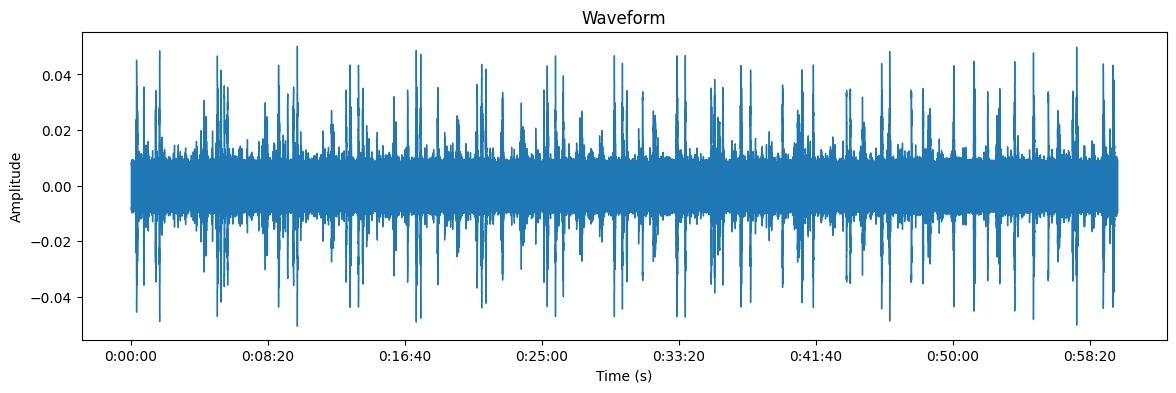

In [ ]:
# Plot waveform
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

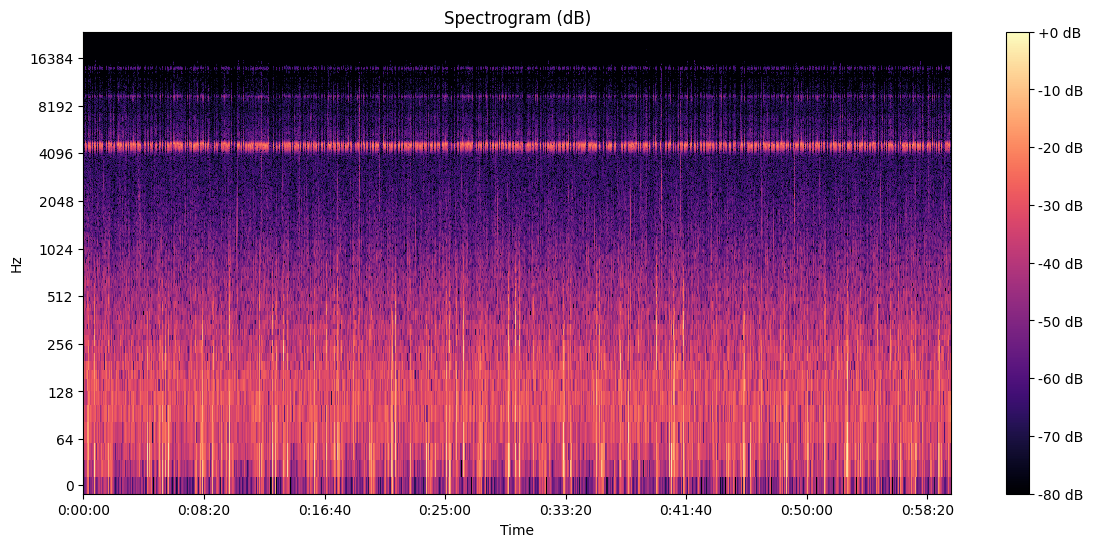

In [ ]:
# Plot spectrogram
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
plt.figure(figsize=(14, 6))
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram (dB)')
plt.show()

In [7]:
# Basic statistics
print(f"Mean amplitude: {np.mean(y):.4f}")
print(f"Std amplitude: {np.std(y):.4f}")
print(f"Max amplitude: {np.max(y):.4f}")
print(f"Min amplitude: {np.min(y):.4f}")

Mean amplitude: 0.0000
Std amplitude: 0.0029
Max amplitude: 0.0436
Min amplitude: -0.0503


In [8]:
def y_slice(length: float, start_sec: float = 0.0, bandpass=[4200, 4860]):
    """
    Slice the audio signal y into segments of specified length.
    
    :param y: Audio signal
    :param length: Length of each segment in seconds
    :param start_sec: Start time in seconds for slicing
    :return: List of audio segments
    """
    start_sample = int(start_sec * sr)
    end_sample = start_sample + int(length * sr)
    sample = y[start_sample:end_sample]

    if bandpass:
        from scipy.signal import butter, sosfilt
        sos = butter(N=6, Wn=bandpass, btype='bandpass', fs=sr, output='sos')
        sample = sosfilt(sos, sample)

    return sample

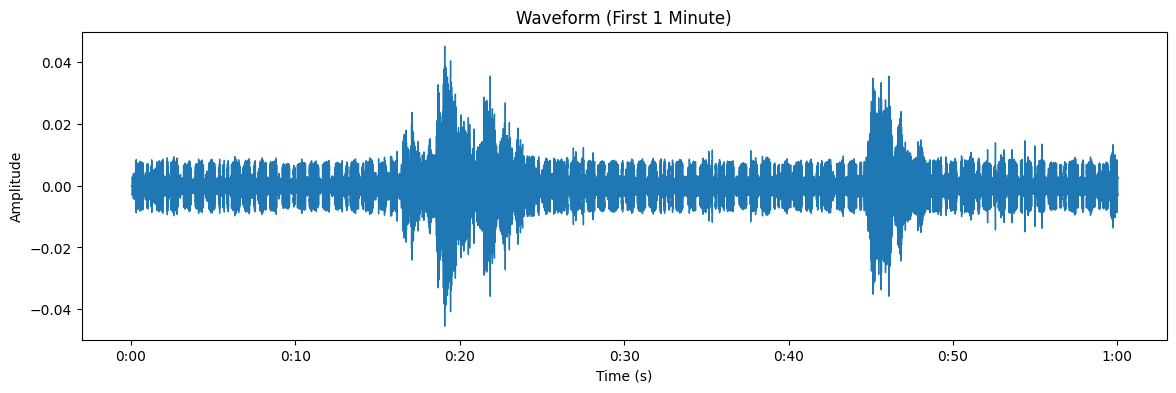

In [9]:
slice = y_slice(60, bandpass=None)

plt.figure(figsize=(14, 4))
librosa.display.waveshow(slice, sr=sr)
plt.title("Waveform (First 1 Minute)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

ipd.Audio(slice, rate=sr)

Dominant frequencies in the first 10 seconds (Hz):
95.30 Hz (magnitude: 60.06)
91.60 Hz (magnitude: 37.42)
4617.20 Hz (magnitude: 36.88)
62.50 Hz (magnitude: 35.80)
4645.70 Hz (magnitude: 32.29)


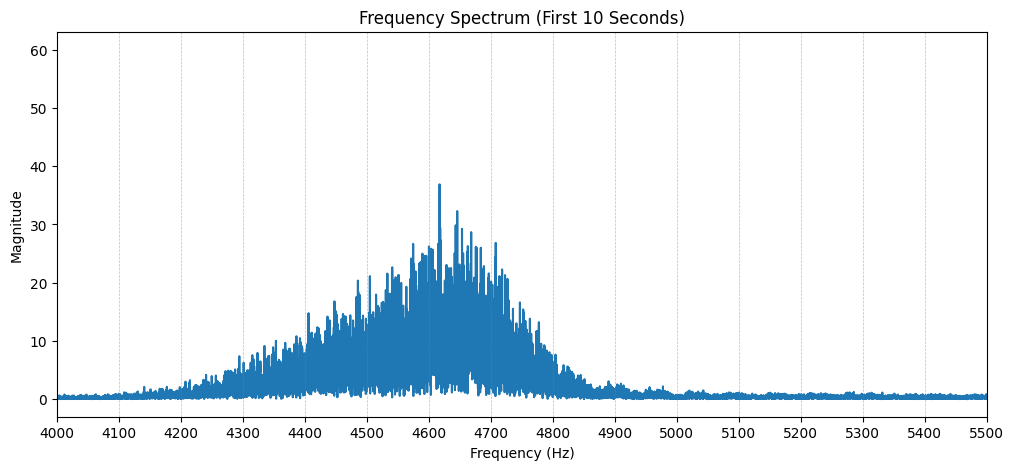

In [10]:
# Analyze dominant frequencies in the first 10 seconds
slice = y_slice(10, bandpass=None)

# Compute FFT
fft_spectrum = np.fft.rfft(slice)
freq = np.fft.rfftfreq(len(slice), d=1/sr)
magnitude = np.abs(fft_spectrum)

# Find dominant frequencies
top_n = 5
indices = np.argsort(magnitude)[-top_n:][::-1]
dominant_freqs = freq[indices]
dominant_mags = magnitude[indices]

print("Dominant frequencies in the first 10 seconds (Hz):")
for f, m in zip(dominant_freqs, dominant_mags):
    print(f"{f:.2f} Hz (magnitude: {m:.2f})")

# Plot the spectrum
plt.figure(figsize=(12, 5))
plt.plot(freq, magnitude)
plt.title("Frequency Spectrum (First 10 Seconds)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(4000, 5500)
plt.xticks(np.arange(4000, 5501, 100))
for hz in np.arange(4000, 5501, 100):
    plt.axvline(hz, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.show()

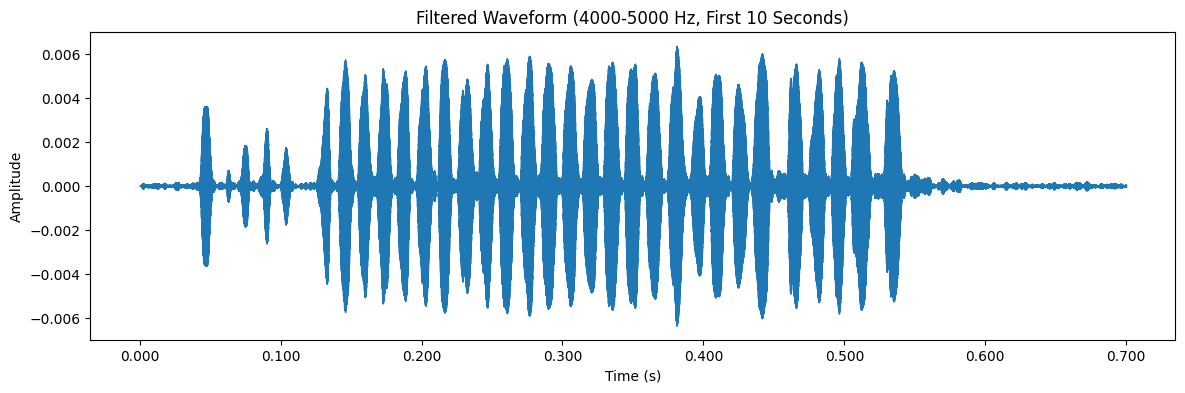

In [13]:
slice = y_slice(0.7, start_sec=1.4)

# Plot the filtered waveform
plt.figure(figsize=(14, 4))
librosa.display.waveshow(slice, sr=sr)
plt.title("Filtered Waveform (4000-5000 Hz, First 10 Seconds)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# Listen to the filtered audio
ipd.Audio(slice, rate=sr)

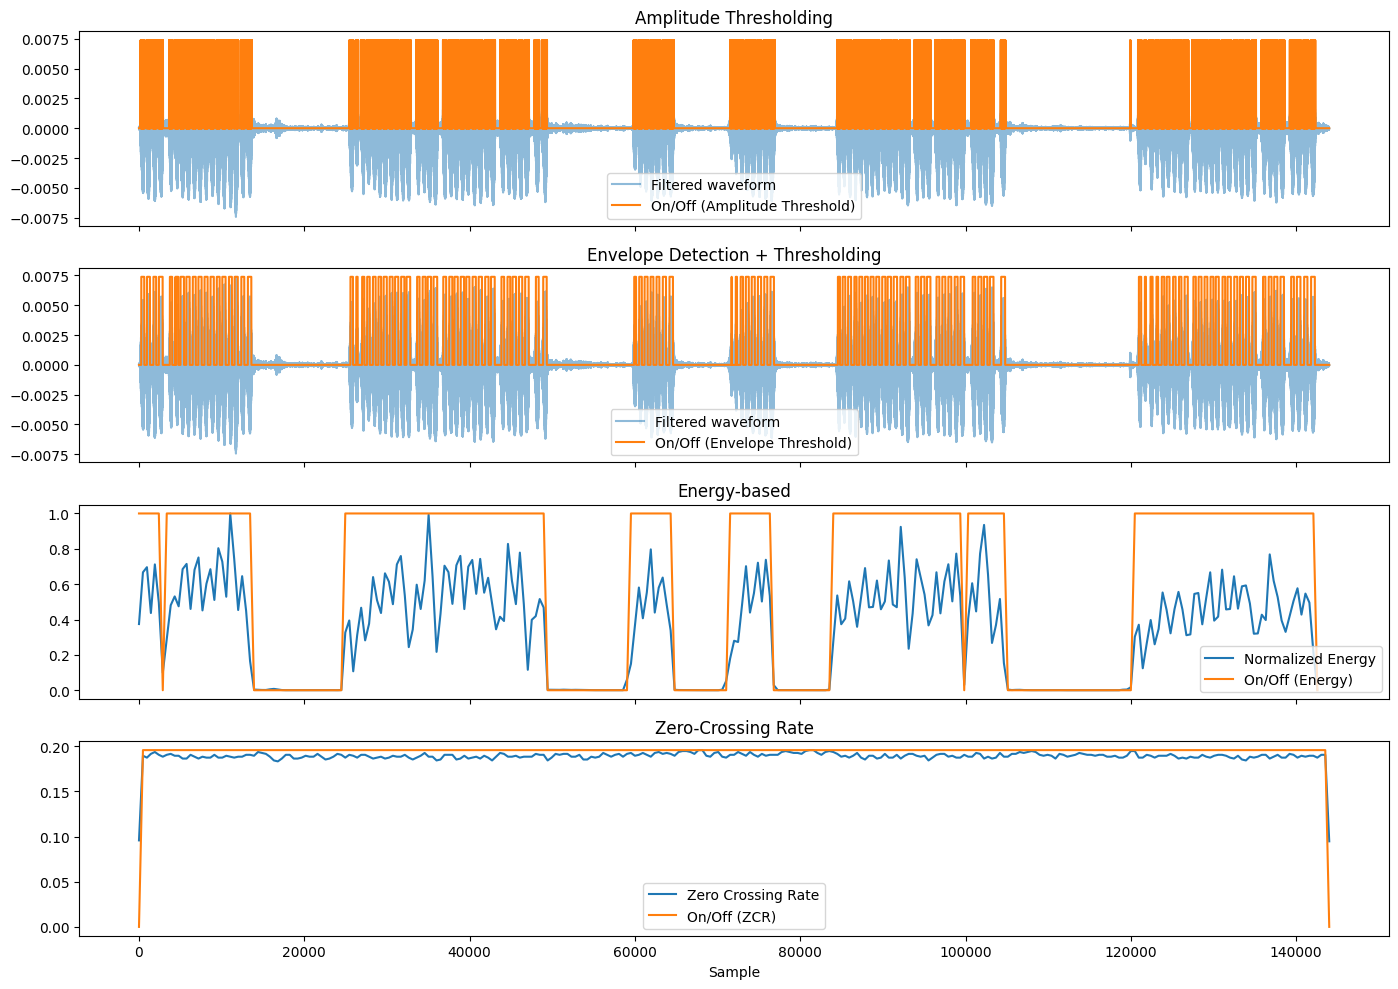

In [164]:
slice = y_slice(3, start_sec=554)

# There are several ways to discretize a waveform into an on/off (binary) pattern.
# Here are some common approaches:

# 1. Amplitude Thresholding: Mark as "on" if amplitude exceeds a threshold.
threshold = 0.001  # Example threshold, adjust as needed
on_off_amplitude = (np.abs(slice) > threshold).astype(int)

# 2. Envelope Detection + Thresholding: Use the amplitude envelope for smoother detection.
from scipy.signal import hilbert
envelope = np.abs(hilbert(slice))
envelope_threshold = 0.0025
on_off_envelope = (envelope > envelope_threshold).astype(int)

# 3. Energy-based: Compute short-time energy and threshold.
frame_length = int(sr * 0.02)  # 10 ms frames
hop_length = frame_length // 2
energy = np.array([
    np.sum(slice[i:i+frame_length]**2)
    for i in range(0, len(slice)-frame_length, hop_length)
])
energy_threshold = .001
on_off_energy = (energy > energy_threshold).astype(int)

# 4. Zero-Crossing Rate: High ZCR may indicate "on" state for some signals.
zcr = librosa.feature.zero_crossing_rate(slice, frame_length=frame_length, hop_length=hop_length)[0]
zcr_threshold = 0.1
on_off_zcr = (zcr > zcr_threshold).astype(int)

fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axs[0].plot(slice, alpha=0.5, label='Filtered waveform')
axs[0].plot(on_off_amplitude * np.max(slice), label='On/Off (Amplitude Threshold)')
axs[0].legend()
axs[0].set_title("Amplitude Thresholding")

axs[1].plot(slice, alpha=0.5, label='Filtered waveform')
axs[1].plot(on_off_envelope * np.max(slice), label='On/Off (Envelope Threshold)')
axs[1].legend()
axs[1].set_title("Envelope Detection + Thresholding")

axs[2].plot(np.arange(len(energy)) * hop_length, energy / np.max(energy), label='Normalized Energy')
axs[2].plot(np.arange(len(on_off_energy)) * hop_length, on_off_energy, label='On/Off (Energy)')
axs[2].legend()
axs[2].set_title("Energy-based")

axs[3].plot(np.arange(len(zcr)) * hop_length, zcr, label='Zero Crossing Rate')
axs[3].plot(np.arange(len(on_off_zcr)) * hop_length, on_off_zcr * np.max(zcr), label='On/Off (ZCR)')
axs[3].legend()
axs[3].set_title("Zero-Crossing Rate")

plt.xlabel("Sample")
plt.tight_layout()
plt.show()

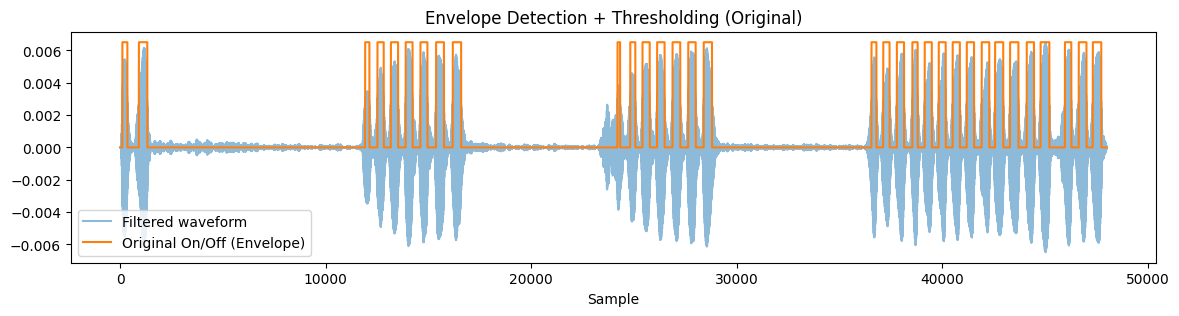

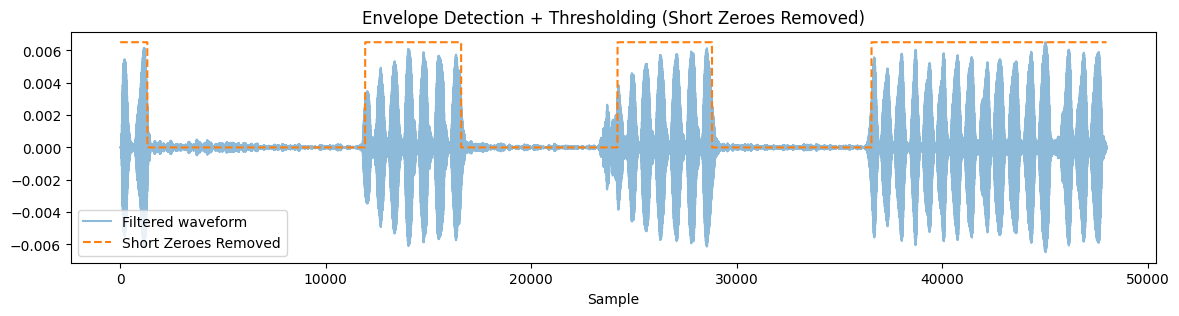

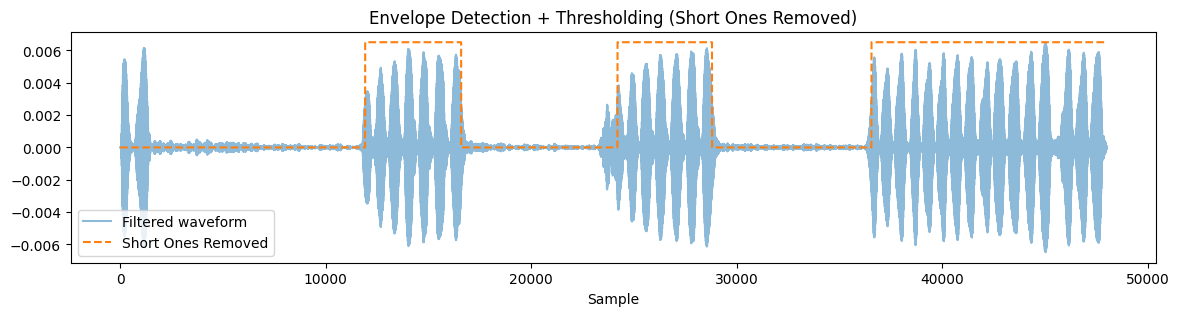

In [172]:
from scipy.ndimage import label

def remove_short_ones(binary_array, min_one_length=sr//10):  # 240 samples = 5ms at 48kHz
    # Invert to find one runs
    labeled, num_features = label(binary_array)
    cleaned = binary_array.copy()
    for i in range(1, num_features + 1):
        indices = np.where(labeled == i)[0]
        if len(indices) < min_one_length:
            cleaned[indices] = 0
    return cleaned

def remove_short_zeros(binary_array, min_zero_length=sr//10):  # 240 samples = 5ms at 48kHz
    # Invert to find zero runs
    inverted = 1 - binary_array
    labeled, num_features = label(inverted)
    cleaned = binary_array.copy()
    for i in range(1, num_features + 1):
        indices = np.where(labeled == i)[0]
        if len(indices) < min_zero_length:
            cleaned[indices] = 1
    return cleaned

def plot_envelopes(slice, on_off_envelope, short_zeroes_removed, short_ones_removed):
    # Plot with short ones removed
    plt.figure(figsize=(14, 3))
    plt.plot(slice, alpha=0.5, label='Filtered waveform')
    plt.plot(on_off_envelope * np.max(slice), label='Original On/Off (Envelope)')
    plt.legend()
    plt.title("Envelope Detection + Thresholding (Original)")
    plt.xlabel("Sample")
    plt.show()

    plt.figure(figsize=(14, 3))
    plt.plot(slice, alpha=0.5, label='Filtered waveform')
    plt.plot(short_zeroes_removed * np.max(slice), label='Short Zeroes Removed', linestyle='--')
    plt.legend()
    plt.title("Envelope Detection + Thresholding (Short Zeroes Removed)")
    plt.xlabel("Sample")
    plt.show()

    plt.figure(figsize=(14, 3))
    plt.plot(slice, alpha=0.5, label='Filtered waveform')
    plt.plot(short_ones_removed * np.max(slice), label='Short Ones Removed', linestyle='--')
    plt.legend()
    plt.title("Envelope Detection + Thresholding (Short Ones Removed)")
    plt.xlabel("Sample")
    plt.show()

slice = y_slice(1, start_sec=555)

def group_features(slice):
    from scipy.signal import hilbert
    envelope = np.abs(hilbert(slice))
    envelope_threshold = 0.0027
    on_off_envelope = (envelope > envelope_threshold).astype(int)

    # Remove short zero sequences (e.g., less than 5ms)
    short_zeroes_removed = remove_short_zeros(on_off_envelope, min_zero_length=int(0.025 * sr))
    #short_ones_removed = on_off_envelope
    short_ones_removed = remove_short_ones(short_zeroes_removed, min_one_length=int(0.05 * sr))

    return on_off_envelope, short_zeroes_removed, short_ones_removed

on_off_envelope, short_zeroes_removed, short_ones_removed = group_features(slice)
plot_envelopes(slice, on_off_envelope, short_zeroes_removed, short_ones_removed)

In [126]:
slice_10 = y_slice(10, start_sec=115)
features_10 = group_features(slice_10)

In [54]:
slice_60 = y_slice(60, start_sec=0)
features_60 = group_features(slice)

In [173]:
# Slice and group features in 60-second chunks for the entire audio
duration_sec = len(y) / sr
chunk_length = 60  # seconds

slices = []
features_list = []

for start_sec in np.arange(0, duration_sec, chunk_length):
    # Calculate end of chunk, add 1 second overlap if not the last chunk
    end_sec = min(start_sec + chunk_length + 3, duration_sec)
    actual_length = end_sec - start_sec
    s = y_slice(actual_length, start_sec=start_sec)
    slices.append(s)
    features_list.append(group_features(s))
    print(f"Processed chunk starting at {start_sec:.2f} seconds (length: {actual_length:.2f}s)")

Processed chunk starting at 0.00 seconds (length: 63.00s)
Processed chunk starting at 60.00 seconds (length: 63.00s)
Processed chunk starting at 120.00 seconds (length: 63.00s)
Processed chunk starting at 180.00 seconds (length: 63.00s)
Processed chunk starting at 240.00 seconds (length: 63.00s)
Processed chunk starting at 300.00 seconds (length: 63.00s)
Processed chunk starting at 360.00 seconds (length: 63.00s)
Processed chunk starting at 420.00 seconds (length: 63.00s)
Processed chunk starting at 480.00 seconds (length: 63.00s)
Processed chunk starting at 540.00 seconds (length: 63.00s)
Processed chunk starting at 600.00 seconds (length: 63.00s)
Processed chunk starting at 660.00 seconds (length: 63.00s)
Processed chunk starting at 720.00 seconds (length: 63.00s)
Processed chunk starting at 780.00 seconds (length: 63.00s)
Processed chunk starting at 840.00 seconds (length: 63.00s)
Processed chunk starting at 900.00 seconds (length: 63.00s)
Processed chunk starting at 960.00 seconds 

In [174]:
import time


def extract_timestamps(binary_array, sr, offset=0.0):
    # Find transitions
    changes = np.diff(binary_array, prepend=0)
    starts = np.where(changes == 1)[0]
    stops = np.where(changes == -1)[0]
    # Handle case where signal ends with an "on"
    if len(starts) > len(stops):
        stops = np.append(stops, len(binary_array))
    # Convert to seconds
    timestamps = [(start / sr + offset, stop / sr + offset) for start, stop in zip(starts, stops)]
    return timestamps

def compute_statistics(feature_timestamps):
    """
    Compute statistics for feature lengths.
    
    :param feature_timestamps: List of tuples (start, stop) in seconds
    :return: Dictionary with min, max, mean, std
    """
    lengths = [stop - start for start, stop in feature_timestamps]

    stats = {
        'n': len(lengths),
        'min': np.min(lengths),
        'max': np.max(lengths),
        'mean': np.mean(lengths),
        'std': np.std(lengths)
    }

    # Find suspected outliers: durations more than 2 std from mean
    stats['outliers'] = [(start, stop) for start, stop in feature_timestamps if abs((stop - start) - stats['mean']) > 3 * stats['std']]
    return stats

def print_statistics(stats):
    print(f"Count: {stats['n']}")
    print(f"Min: {stats['min']:.4f}")
    print(f"Max: {stats['max']:.4f}")
    print(f"Mean: {stats['mean']:.4f}")
    print(f"Std: {stats['std']:.4f}")
    if len(stats['outliers']) > 0:
        print(f"\nSuspected outliers (>3 std from mean): {len(stats['outliers'])}")
        for i, (start, stop) in enumerate(stats['outliers'][:10]):
            print(f"{i+1}: Start={start:.4f}, Stop={stop:.4f}, Duration={stop-start:.4f}")
        if len(stats['outliers']) > 10:
            print("...")

#slice = slice_all
#features = features_all
# *_, grouped_features = features_list[0]

#features = [f[2] for f in features_list]  # Unpack the tuples
#merged_features = np.concatenate(features)

# # Merge features at the boundaries when concatenating
# # If the last value of the previous chunk and the first value of the next chunk are both 1, merge them
# merged_features = []
# for i, feat in enumerate(features):
#     if i > 0 and merged_features and merged_features[-1] == 1 and feat[0] == 1:
#         # Remove the boundary zero and continue the run
#         merged_features.extend(feat[1:])
#     else:
#         merged_features.extend(feat)
#grouped_features = np.array(merged_features)

feature_timestamps = set()

for index, (*_, grouped_features) in enumerate(features_list):
    timestamps = extract_timestamps(grouped_features, sr, offset=index * 60)
    if len(timestamps) == 0:
        continue
    feature_timestamps.update(timestamps[0 if index == 0 else 1:-1])

feature_timestamps = sorted(feature_timestamps, key=lambda x: x[0])
# feature_timestamps = extract_timestamps(merged_features, sr)

# feature_timestamps = []

# for i, (*_, grouped_features) in enumerate(features_list):
#     timestamps = extract_timestamps(grouped_features, sr, offset=i * 60)
#     if len(timestamps) == 0:
#         break
#     if len(feature_timestamps) > 0:
#         last_feature = feature_timestamps.pop()
#         timestamps[0] = (last_feature[0], timestamps[0][1])  # Merge start timestamp
#     feature_timestamps.extend(timestamps)

print("First 5 envelope on/off timestamps: \n" + '\n'.join(f"{start:.3f}, {stop:.3f}" for start, stop in feature_timestamps[:5]))

First 5 envelope on/off timestamps: 
0.264, 0.708
0.937, 1.034
1.179, 1.276
1.530, 1.939
2.150, 2.247


Feature length statistics (seconds):
Count: 6858
Min: 0.0953
Max: 0.5765
Mean: 0.3128
Std: 0.1859
dits statistics:
Count: 2830
Min: 0.0953
Max: 0.0993
Mean: 0.0973
Std: 0.0005

Suspected outliers (>3 std from mean): 5
1: Start=354.1281, Stop=354.2234, Duration=0.0953
2: Start=1011.3706, Stop=1011.4662, Duration=0.0956
3: Start=1702.4691, Stop=1702.5645, Duration=0.0954
4: Start=3512.0380, Stop=3512.1334, Duration=0.0954
5: Start=3594.2570, Stop=3594.3563, Duration=0.0993

dahs statistics:
Count: 4028
Min: 0.4050
Max: 0.5765
Mean: 0.4642
Std: 0.0570


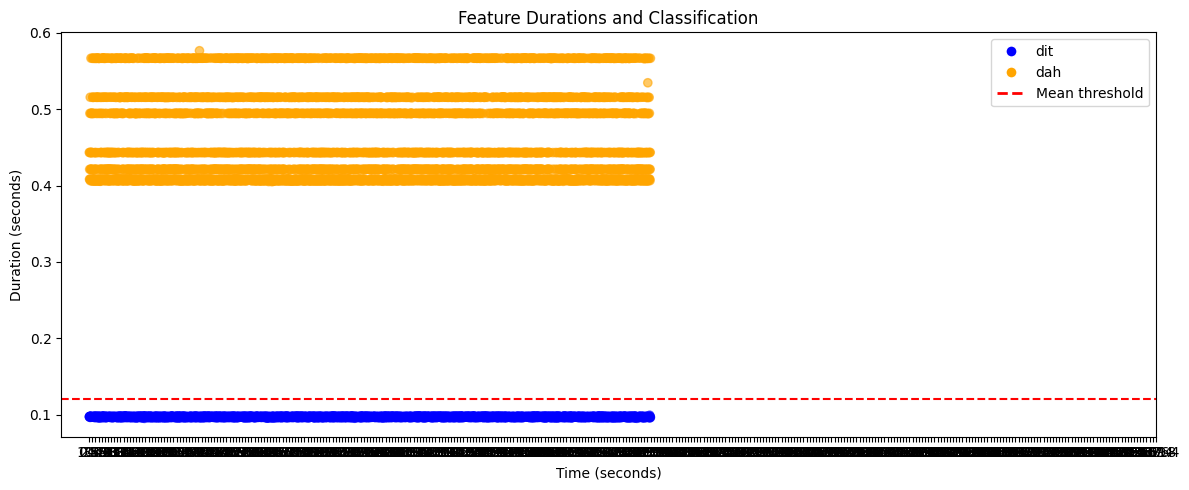

In [175]:
import numpy as np

print(f"Feature length statistics (seconds):")
stats = compute_statistics(feature_timestamps)
print_statistics(stats)

# Classify features as 'dits' or 'dahs' based on their duration
# We'll use the mean_length as a threshold: shorter than mean is 'dit', longer is 'dah'

dits = []
dahs = []

#threshold = stats['mean']
threshold = 0.12

for start, stop in feature_timestamps:
    duration = stop - start
    if duration < threshold:
        dits.append((start, stop))
    else:
        dahs.append((start, stop))

print("dits statistics:")
print_statistics(compute_statistics(dits))

print("\ndahs statistics:")
print_statistics(compute_statistics(dahs))

import matplotlib.pyplot as plt

# plt.figure(figsize=(14, 3))
# plt.plot(slice, alpha=0.5, label='Filtered waveform')
# plt.plot(grouped_features * np.max(slice), label='Short Ones Removed', linestyle='--')
# plt.legend()
# plt.title("Envelope Detection + Thresholding (Short Ones Removed)")
# plt.xlabel("Sample")
# plt.show()

# Prepare data for plotting
lengths = [stop - start for start, stop in feature_timestamps]
labels = ['dit' if (stop - start) < threshold else 'dah' for start, stop in feature_timestamps]
colors = ['blue' if label == 'dit' else 'orange' for label in labels]

plt.figure(figsize=(12, 5))
x_pos = [(start + stop) / 2 for start, stop in feature_timestamps]
plt.scatter(x_pos, lengths, c=colors, alpha=0.6, label='Features')
plt.axhline(threshold, color='red', linestyle='--', label='Mean threshold')
plt.xlabel('Time (seconds)')
# Set x-ticks to show the start time (in seconds) of each feature
plt.xticks(
    ticks=np.arange(0, len(lengths), step=20), 
    labels=[f"{feature_timestamps[i][0]:.1f}" for i in np.arange(0, len(lengths), step=20)]
)
plt.ylabel('Duration (seconds)')
plt.title('Feature Durations and Classification')
plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', label='dit', markerfacecolor='blue', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='dah', markerfacecolor='orange', markersize=8),
    plt.Line2D([0], [0], color='red', lw=2, linestyle='--', label='Mean threshold')
])
plt.tight_layout()
plt.show()


In [147]:
def print_timestamps(ft, begin, end):
    for start, stop in ft:
        if start >= begin and stop <= end:
            print(f"Feature from {start:.2f}s to {stop:.2f}s")

print_timestamps(feature_timestamps, 115, 125)

Feature from 115.41s to 115.92s
Feature from 116.17s to 116.26s
Feature from 116.42s to 116.99s
Feature from 117.23s to 117.66s
Feature from 117.99s to 118.44s
Feature from 118.80s to 119.21s
Feature from 119.41s to 120.00s
Feature from 120.24s to 120.66s
Feature from 120.99s to 121.44s
Feature from 121.75s to 122.16s
Feature from 122.37s to 122.47s
Feature from 122.63s to 123.04s
Feature from 123.29s to 123.71s
Feature from 124.05s to 124.49s


In [ ]:
sl = y_slice()
plt.figure(figsize=(14, 3))
plt.plot(slice, alpha=0.5, label='Filtered waveform')
plt.plot(grouped_features * np.max(slice), label='Short Ones Removed', linestyle='--')
plt.legend()
plt.title("Envelope Detection + Thresholding (Short Ones Removed)")
plt.xlabel("Sample")
plt.show()


In [176]:
def timestamps_to_morse(timestamps, threshold=0.12):
    """
    Convert a list of (start, stop) timestamps into a string of '.' (dit) and '-' (dah).
    :param timestamps: list of (start, stop) tuples
    :param threshold: duration threshold to distinguish dit/dah
    :return: string of '.' and '-'
    """
    morse = []
    for start, stop in timestamps:
        duration = stop - start
        if duration < threshold:
            morse.append('.')
        else:
            morse.append('-')
    return ''.join(morse)

morse_string = timestamps_to_morse(feature_timestamps, threshold)
print(morse_string)

-..-.----...--.---.----.-.---------.---.--.--.-.---.---....---....----..---..---.-.----.-.-.-.-.--.---..-.-...--..-..---..-..-.-.-.-...---.-.---...-.-----.-....--..-.-.-...--..-..-.--..---..----.---...-..--.-..--.-..-...--.---.--------..----..-.--.-..--.-.-.----.---...----.----.---...---.--.----.-....----.----..----..---.----.-----.-.----..---....----..---..---...-..-..--.---..-.-.-..--.-...---....-.-.-----..---...--.-..----.-.-...--....-.-.-.-..--.--.--...--.-----..---..-----.----.----.---.-.-.-.-.------..--..---.-..-.-.-..-------.---.--...-.--...----..---.--.----.---.--..---.----....------...-..----.-.-.-..----.-.--.-.--.--.-....---..-.--..-.----.---.--..---..--..-..--..-..--..-.-...----..-----------....--..-.--.-..--.--.-.--.---...---.-.--..-.---.---.-...--..-.---.--.--.----.----...---..---...---.-.-.-.--.....--.-...----.--.-.---.....---..----..---..--.-...-..-..----.--.-....-.---..--.-----..--..---....--------..---.....---..----..---...-----.---.....--.-..----..-----.-.-------.-..-